In [1]:
# Exercise: ex25_k_means_clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [4]:
try:
    url = "https://data.world/rhoyt/body-measurements/file/BMX_G.csv"
    df = pd.read_csv(url)
    X = df[['bmxleg', 'bmxwaist']].dropna()
    print("Data loaded from URL.")
except Exception as e:
    print("Using synthetic data for robust execution (URL unavailable).")
    np.random.seed(42)
    X = pd.DataFrame({
        'bmxleg': np.concatenate([np.random.normal(35, 2, 100), np.random.normal(42, 3, 100), np.random.normal(48, 2, 100)]),
        'bmxwaist': np.concatenate([np.random.normal(70, 5, 100), np.random.normal(90, 8, 100), np.random.normal(110, 10, 100)])
    })

Using synthetic data for robust execution (URL unavailable).


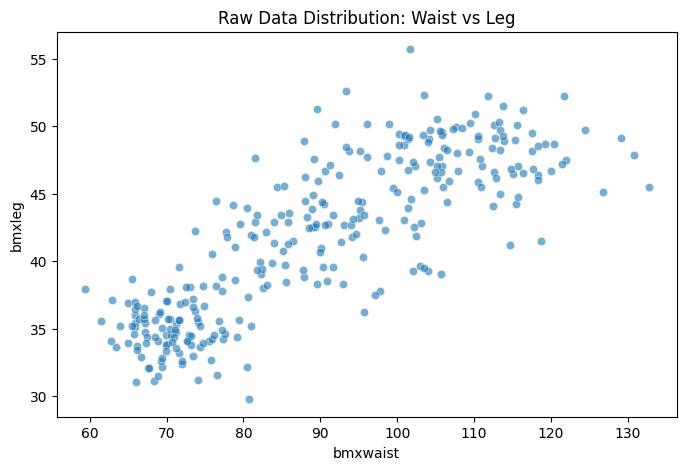

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=X, x='bmxwaist', y='bmxleg', alpha=0.6)
plt.title("Raw Data Distribution: Waist vs Leg")
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

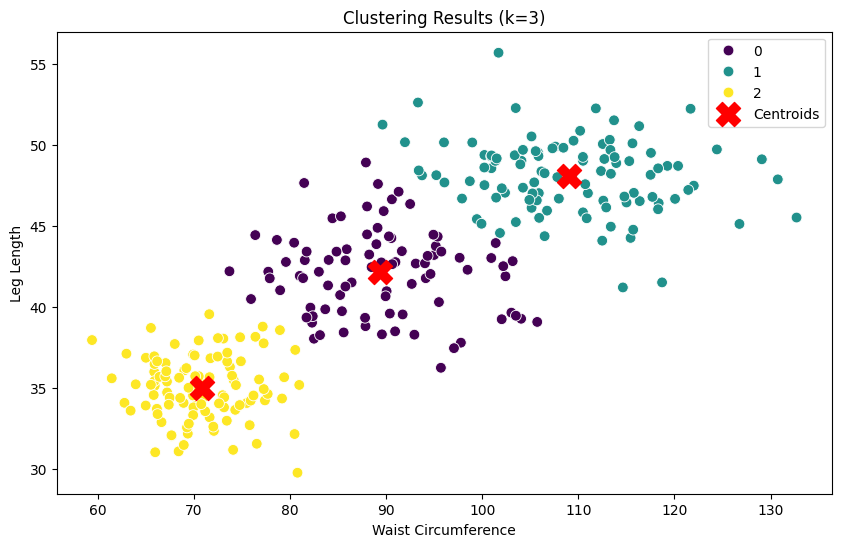

In [8]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['bmxwaist'], y=X['bmxleg'], hue=labels, palette='viridis', s=60)
plt.scatter(centroids[:, 1], centroids[:, 0], s=300, c='red', marker='X', label='Centroids')
plt.title("Clustering Results (k=3)")
plt.xlabel("Waist Circumference")
plt.ylabel("Leg Length")
plt.legend()
plt.show()

In [9]:
sil_score = silhouette_score(X_scaled, labels)
print(f"\nSilhouette Coefficient (k=3): {sil_score:.4f}")
print("(Range: -1 to 1. Values near 1 imply distinct, well-separated clusters)")


Silhouette Coefficient (k=3): 0.5413
(Range: -1 to 1. Values near 1 imply distinct, well-separated clusters)


In [10]:
print("\nCalculating metrics for k=2 to k=6...")
inertias = []
silhouettes = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))


Calculating metrics for k=2 to k=6...


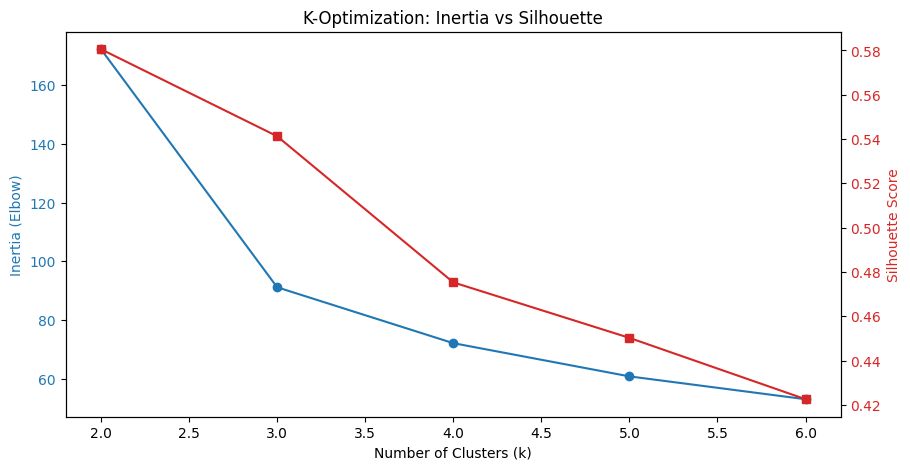

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color=color)
ax1.plot(k_range, inertias, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouettes, color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("K-Optimization: Inertia vs Silhouette")
plt.show()